In [108]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.base import BaseEstimator, OneToOneFeatureMixin, TransformerMixin
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression


In [77]:
data = pd.read_csv("train.csv", index_col="id")
data.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
id,,,,,,,,
0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [78]:
num_cols = [
    "Time_spent_Alone",
    "Social_event_attendance",
    "Going_outside",
    "Friends_circle_size",
    "Post_frequency",
]
cat_cols = [
    "Stage_fear",
    "Drained_after_socializing",
]
cat_index = [data.columns.get_loc(col) for col in cat_cols]
feature_cols = num_cols + cat_cols
target_col = "Personality"

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18524 entries, 0 to 18523
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           17334 non-null  float64
 1   Stage_fear                 16631 non-null  object 
 2   Social_event_attendance    17344 non-null  float64
 3   Going_outside              17058 non-null  float64
 4   Drained_after_socializing  17375 non-null  object 
 5   Friends_circle_size        17470 non-null  float64
 6   Post_frequency             17260 non-null  float64
 7   Personality                18524 non-null  object 
dtypes: float64(5), object(3)
memory usage: 1.3+ MB


In [59]:
class CustomLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        super().__init__()
        self.encoders = {}

    def fit(self, X: pd.DataFrame, y=None):
        for col in X.columns:
            self.encoders[col] = LabelEncoder().fit(X[col])
        return self

    def transform(self, X: pd.DataFrame):
        X_transformed = X.copy()
        for col in X.columns:
            X_transformed[col] = self.encoders[col].transform(X_transformed[col])
        return X_transformed

    def get_feature_names_out(self, input_features=None):
        return input_features

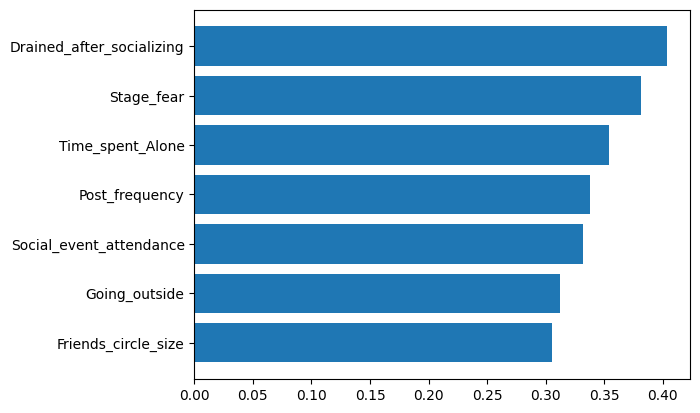

In [ ]:
preprocessor = make_column_transformer(
    (SimpleImputer(strategy="most_frequent"), num_cols),
    (CustomLabelEncoder(), cat_cols),
    verbose_feature_names_out=False,
)
le = LabelEncoder()

X = preprocessor.fit_transform(data[feature_cols])
y = le.fit_transform(data[target_col])

feature_names = preprocessor.get_feature_names_out()
mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "MI_Score": mi_scores,
    }
).sort_values("MI_Score", ascending=True)

bars = plt.barh(mi_df["Feature"], mi_df["MI_Score"])

<Axes: xlabel='Post_frequency', ylabel='Density'>

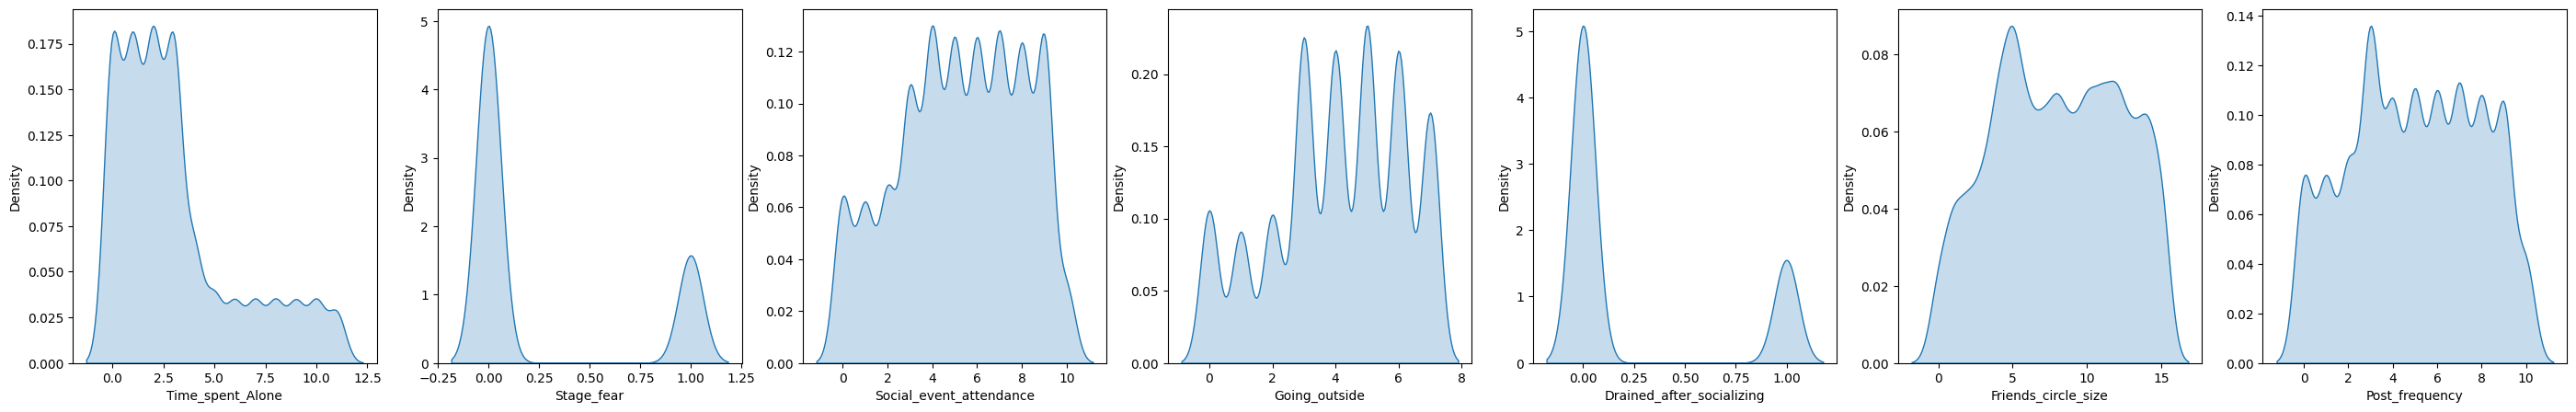

In [86]:
fig, axs = plt.subplots(1, 7, figsize=(35, 5))

preprocessor = make_column_transformer(
    (SimpleImputer(strategy="most_frequent"), num_cols),
    (CustomLabelEncoder(), cat_cols),
    verbose_feature_names_out=False,
)

X = preprocessor.fit_transform(data[feature_cols])

sns.kdeplot(data.Time_spent_Alone, fill=True, ax=axs[0])
sns.kdeplot(data.Stage_fear.map({"No": 0, "Yes": 1}), fill=True, ax=axs[1])
sns.kdeplot(data.Social_event_attendance, fill=True, ax=axs[2])
sns.kdeplot(data.Going_outside, fill=True, ax=axs[3])
sns.kdeplot(
    data.Drained_after_socializing.map({"No": 0, "Yes": 1}), fill=True, ax=axs[4]
)
sns.kdeplot(data.Friends_circle_size, fill=True, ax=axs[5])
sns.kdeplot(data.Post_frequency, fill=True, ax=axs[6])


In [ ]:
from sklearn.decomposition import PCA

preprocessor = make_column_transformer(
    (
        make_pipeline(SimpleImputer(strategy="most_frequent"), StandardScaler()),
        num_cols,
    ),
)

X = preprocessor.fit_transform(data[feature_cols])

pca = PCA()
X_pca = pca.fit_transform(X)
pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i + 1}" for i in range(X_pca.shape[1])],
    index=num_cols,
)

,PC1,PC2,PC3,PC4,PC5
Time_spent_Alone,0.462768,-0.003546,-0.053022,-0.105466,0.878578
Social_event_attendance,-0.451877,0.102367,-0.153169,0.809540,0.326362
Going_outside,-0.445233,-0.295774,0.786319,-0.167439,0.260675
Friends_circle_size,-0.435485,0.763459,-0.108825,-0.430450,0.174222
Post_frequency,-0.440197,-0.564940,-0.586163,-0.346697,0.152589


In [110]:
mutual_info_regression(X_pca, y, random_state=42)

array([0.43741613, 0.0727156 , 0.06861386, 0.05305534, 0.07517336])

In [25]:
preprocessor = make_column_transformer(
    (CustomLabelEncoder(), cat_cols), remainder="passthrough"
)
le = LabelEncoder()

X = preprocessor.fit_transform(data[feature_cols])
y = le.fit_transform(data[target_col])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [ ]:
from sklearn.feature_selection import mutual_info_classif


def make_mi_scores(X, y):
    mi_scores = mutual_info_classif(X, y, discrete_features=True)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


mutual_info_classif(X, y, discrete_features=True)
# mi_scores = make_mi_scores(X, y)
# mi_scores[::3]  # show a few features with their MI scores

ValueError: Input X contains NaN.

In [ ]:
plt.figure(dpi=100, figsize=(8, 5))
scores = scores.sort_values(ascending=True)
width = np.arange(len(scores))
ticks = list(scores.index)
plt.barh(width, scores)
plt.yticks(width, ticks)
plt.title("Mutual Information Scores")


In [7]:
train_data = lgb.Dataset(
    X_train, label=y_train, categorical_feature=cat_index, free_raw_data=False
)

test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, free_raw_data=False)

In [ ]:
import optuna


def objective(trial):
    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 1),
        "feature_pre_filter": False,
        "random_state": 42,
        "verbosity": -1,
    }

    model = lgb.train(
        params,
        train_data,
        num_boost_round=500,
        valid_sets=[test_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
        ],
    )

    preds = model.predict(X_test)
    preds = (model.predict(X_test) > 0.5).astype(int)
    return accuracy_score(y_test, preds)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
print(
    f"Optuna Model: Accuracy={study.best_value:.4f}, Best Params: {study.best_params}"
)

[I 2025-07-05 18:46:06,765] A new study created in memory with name: no-name-c31e90b1-cf31-48ec-a38a-35987158f443
[I 2025-07-05 18:46:07,295] Trial 0 finished with value: 0.9649053591650972 and parameters: {'learning_rate': 0.10757488232089907, 'num_leaves': 99, 'max_depth': 12, 'min_child_samples': 44, 'reg_alpha': 0.8124152495163702, 'reg_lambda': 0.3822585436599856}. Best is trial 0 with value: 0.9649053591650972.
[I 2025-07-05 18:46:07,511] Trial 1 finished with value: 0.9654250367055648 and parameters: {'learning_rate': 0.02950287084455757, 'num_leaves': 20, 'max_depth': 8, 'min_child_samples': 38, 'reg_alpha': 0.1187839834175517, 'reg_lambda': 0.791896066304792}. Best is trial 1 with value: 0.9654250367055648.
[I 2025-07-05 18:46:07,932] Trial 2 finished with value: 0.9643959836023039 and parameters: {'learning_rate': 0.03164529921215098, 'num_leaves': 92, 'max_depth': 11, 'min_child_samples': 32, 'reg_alpha': 0.7606196684547032, 'reg_lambda': 0.7762574748488593}. Best is trial 1

Optuna Model: Accuracy=0.9676, ROC=0.9643, Best Params: {'learning_rate': 0.24407990754146416, 'num_leaves': 99, 'max_depth': 12, 'min_child_samples': 46, 'reg_alpha': 0.8429484698813318, 'reg_lambda': 0.44756339555177654}


In [19]:
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner


def objective(trial):
    params = {
        "objective": "binary",
        "metric": "accuracy",
        "verbosity": -1,
        "random_state": 42,
        "boosting_type": "gbdt",
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 2, 256),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }

    pruning_callback = optuna.integration.LightGBMPruningCallback(trial, "accuracy")
    model = lgb.train(
        params, train_data, valid_sets=[test_data], callbacks=[pruning_callback]
    )

    preds = model.predict(X_test)
    preds = (model.predict(X_test) > 0.5).astype(int)
    return accuracy_score(y_test, preds)


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(multivariate=True, group=True),
    pruner=HyperbandPruner(),
)
study.optimize(objective, n_trials=50)
print(
    f"Optuna Model: Accuracy={study.best_value:.4f}, Best Params: {study.best_params}"
)

[I 2025-07-05 19:00:54,890] A new study created in memory with name: no-name-cb8aae83-904f-48f1-9cbf-389119b17a41
[W 2025-07-05 19:00:55,020] Trial 0 failed with parameters: {'lambda_l1': 3.1730565715126313, 'lambda_l2': 1.8585342520119502e-07, 'num_leaves': 254, 'feature_fraction': 0.7662774649182289, 'bagging_fraction': 0.5656241948216669, 'bagging_freq': 1, 'min_child_samples': 69} because of the following error: ValueError('The entry associated with the validation name "valid_0" and the metric name "accuracy" is not found in the evaluation result list [].').
Traceback (most recent call last):
  File "/home/yacan/.pyenv/versions/3.12.5/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_70548/647177365.py", line 22, in objective
    model = lgb.train(
            ^^^^^^^^^^
  File "/home/yacan/.pyenv/versions/3.12.5/lib/python3.12/site-packages/lightgbm/engine.py",

ValueError: The entry associated with the validation name "valid_0" and the metric name "accuracy" is not found in the evaluation result list [].